In [1]:
%pip install pandas geopandas numpy matplotlib folium contextily

Note: you may need to restart the kernel to use updated packages.


### CSV-Datei einlesen

In [10]:
import pandas as pd

df = pd.read_csv(
    "data/ungleichheiten.csv",
    header=0,
    delimiter=";",
)
#df.head

### Fehlende Werte behandeln

In [18]:
# Fehlende Werte durch -1 ersetzen
df = df.fillna(-1)
#df.head

### Spaltennamen ändern

In [17]:
df.rename(
    columns={
        "bev_ges_zelle": "Einwohner pro qkm",
        "sgb_quote": "Armutsquote",
        "akad_ant_zelle": "Anteil Akademiker",
        "ant_elb_zelle": "Anteil SGB II Empfänger",
        "ant_4800ein_zelle": "Einkommen > 4800",
        "ant_6600ein_zelle": "Einkommen > 6600",
    },
    inplace=True,
)
#df.head

### Gitterkoordinaten extrahieren und Länge und Breite umwandeln

In [16]:
'''
Die Koordinaten der Spalte "gitter1km" sind im Format "1kmN3254E4569" (Lambert-Projektion ETRS89-LAEA (EPSG:3035))
Sie müssen fur die Hintergrundkarte in WGS84 (EPSG:4326) umgerechnet werden
'''

# Funktion, um Koordinaten aus der Gitter-ID zu extrahieren
def extract_coords(gitter_id):
    parts = gitter_id.split("km")[1].split("N")[1].split("E")
    e = int(parts[0]) * 1000  # Umrechnung in Meter
    n = int(parts[1]) * 1000  # Umrechnung in Meter
    return n, e


# Koordinaten aus der Spalte "gitter1km" extrahieren und in separate Spalten schreiben
df["n"] = df["gitter1km"].apply(lambda x: extract_coords(x)[0])
df["e"] = df["gitter1km"].apply(lambda x: extract_coords(x)[1])

# print(df['e'], df['n'])

'''
Das ETRS89-LAEA-System verwendet False Easting und False Northing von 4321000 bzw. 3210000 Metern. 
Um die Koordinaten korrekt zu transformieren, werden diese Werte addiert
'''
# Koordinaten im ETRS89-LAEA-System anpassen
df["x"] = df["n"] + 4321000
df["y"] = df["e"] + 3210000

# Koordinaten von ETRS89-LAEA in WGS84 umwandeln
import pyproj

# Definieren der Projektionen
etrs_laea = pyproj.Proj("epsg:3035")
wgs84 = pyproj.Proj("epsg:4326")

# Transformieren der Koordinaten
df["lat"], df["lon"] = pyproj.transform(etrs_laea, wgs84, df["x"], df["y"])

# df["lat"], df["lon"]

/var/folders/x9/hgjqdltx0nbf8sq1pmk42p7m0000gn/T/ipykernel_36864/540663889.py:36: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  df["lat"], df["lon"] = pyproj.transform(etrs_laea, wgs84, df["x"], df["y"])


### Stadt und Jahre extrahieren

In [15]:
# Extrahiere alles vor dem Komma und schreibe es in die neue Spalte "stadt"
df["stadt"] = df["gemeindename"].str.extract(r"^(.*?),")

# Gewünschte Stadt
stadt = ["Berlin"]
# Gewünschtes Jahr
jahr = [2021]

# Zeilen extrahieren, die den Namen der Stadt und das Jahr in den jeweiligen Spalten haben
gemeinde_stadt = df[df["stadt"].isin(stadt)]
gemeinde_df = gemeinde_stadt[gemeinde_stadt["jahr"].isin(jahr)]

# gemeinde_df.head

### GeoDataFrames mit Geopandas erstellen

In [7]:
import geopandas as gpd

# Erstelle einen GeoDataFrame mit Geopandas fur die Daten der Tabelle (EPSG:3035)
gdf = gpd.GeoDataFrame(
    gemeinde_df, geometry=gpd.points_from_xy(gemeinde_df["n"], gemeinde_df["e"])
)

# Erstelle einen GeoDataFrame mit Geopandas fur die Hintergrundkarte (EPSG:4326)
ctx_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(
        gemeinde_df["lat"], gemeinde_df["lon"], crs="EPSG:3035"
    ),
)

#gdf.head

### Visualisierung

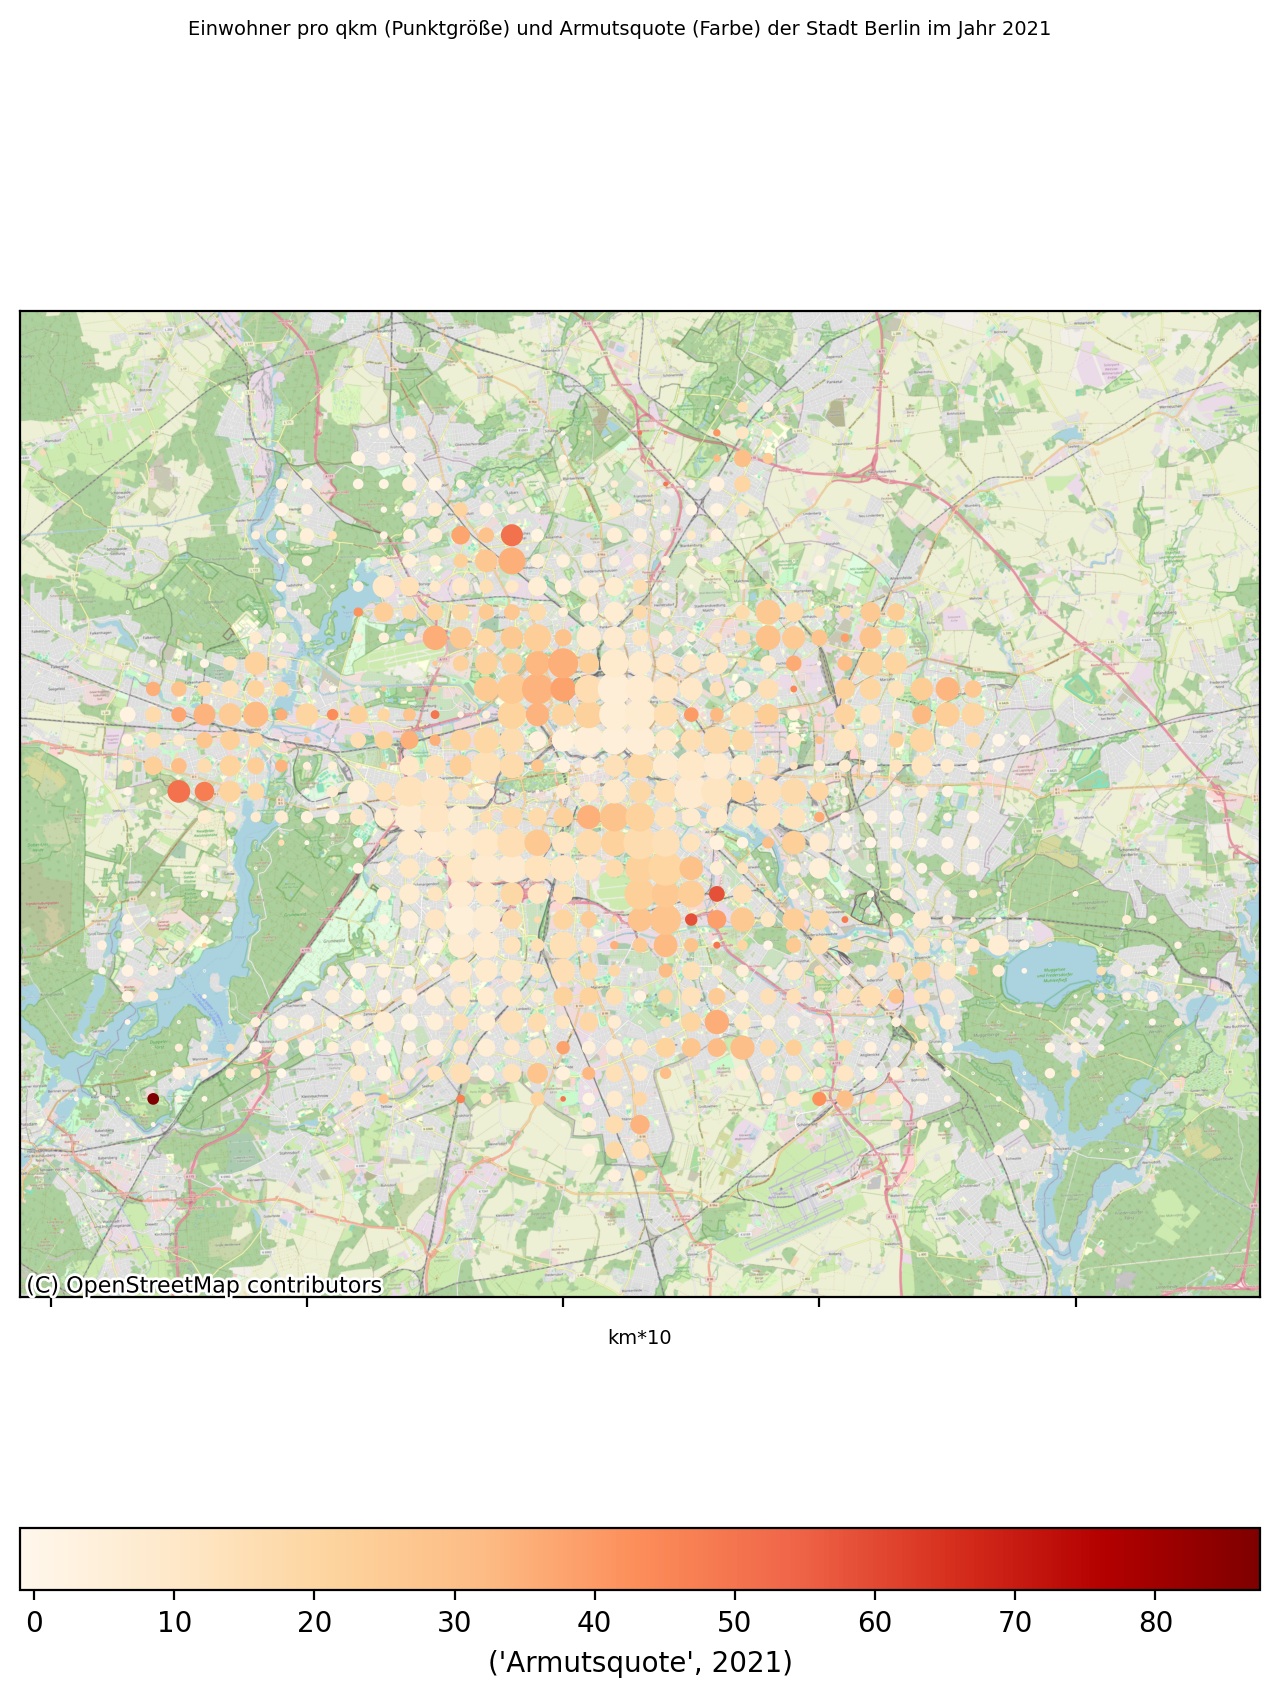

In [8]:
import matplotlib.pyplot as plt
import contextily as ctx
# import cartopy
# import cartopy.crs as ccrs


# Umwandeln in WGS84 (EPSG:4326) mit der Geopandas-Funktion to_crs
back_gdf = ctx_gdf.to_crs(epsg=3857)
# print(back_gdf.crs)

# Visualisierung mit Matplotlib
fig, ax = plt.subplots(figsize=(8, 10), dpi=200)

spalte_farbe = "Armutsquote"
spalte_groesse = "Einwohner pro qkm"

farbe = gemeinde_df[spalte_farbe]  # Spalte, die die Farbe der Markierungen darstellt
groesse = gemeinde_df[spalte_groesse]  # Spalte, die die Groesse der Markierungen darstellt
label = spalte_farbe  # Label fur Farblegende
titel = (
    spalte_groesse
    + " (Punktgröße) und "
    + spalte_farbe
    + " (Farbe) der Stadt "
    + gemeinde_df["stadt"].iloc[0]
    + " im Jahr "
    + gemeinde_df["jahr"].iloc[0].astype(str)
)

gdf.plot(
    ax=ax,
    column=farbe,  # Spalte, die die Farbe der Markierungen darstellt
    cmap="OrRd",  # color map
    legend=True,  # Farblegende
    legend_kwds={
        "label": (label, gemeinde_df["jahr"].iloc[0].item()),
        "orientation": "horizontal",
    },
    markersize=groesse / 2e2,  # Spalte, die die Groesse der Markierungen darstellt
)

plt.suptitle(titel, fontsize=7)  # Titel für den gesamten Plot
ax.get_xaxis().set_ticklabels([])  # Entfernt die x-Ticks
plt.yticks([])  # Entfernt die y-Tick-Labels
plt.xlabel("km*10", fontsize=7)  # Beschriftung der x-Achse

# Hintergrundkarte hinzufügen
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=ctx_gdf.crs, zoom=13)

plt.show()